# Phase 6: ARIMA / SARIMA Baseline Modelling

This notebook implements the execution-plan ARIMA/SARIMA baseline on a stratified sample of 300 bottom-level M5 series.

What this notebook does:
- loads `train.parquet`, `val.parquet`, and `test.parquet`
- filters to non-sparse series (`zero_ratio < 0.70`)
- selects and saves a stratified sample to `configs/arima_sample_ids.txt`
- runs `pmdarima.auto_arima()` with the plan hyperparameters
- fits SARIMAX baselines with a small exogenous feature set (`is_weekend`, `is_event`, `is_snap`, `sell_price`), forecasts validation and test windows, and saves predictions
- computes overall and grouped metrics, logs results to MLflow, and visualizes the baseline end to end


In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ['MPLCONFIGDIR'] = str(ROOT / 'outputs/.matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
(ROOT / 'outputs/figures').mkdir(parents=True, exist_ok=True)
(ROOT / 'outputs/predictions').mkdir(parents=True, exist_ok=True)
(ROOT / 'outputs/models').mkdir(parents=True, exist_ok=True)
(ROOT / 'mlruns').mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore')


In [2]:
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.evaluation.metrics import compute_all_metrics
from src.models.arima_model import (
    ARIMA_EXOG_COLUMNS,
    ARIMA_FAILURES_PATH,
    ARIMA_ORDER_LOG_PATH,
    ARIMA_SAMPLE_PATH,
    ARIMA_TEST_PREDS_PATH,
    ARIMA_VAL_PREDS_PATH,
    build_series_metadata,
    compute_group_metrics,
    filter_non_sparse_series,
    fit_auto_arima,
    log_metrics_to_mlflow,
    run_arima_baseline,
    save_sample_ids,
    select_stratified_sample_ids,
    summarize_order_modes,
)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)


In [3]:
TRAIN_PATH = ROOT / 'data/features/train.parquet'
VAL_PATH = ROOT / 'data/features/val.parquet'
TEST_PATH = ROOT / 'data/features/test.parquet'
MAPPING_PATH = ROOT / 'configs/feature_category_mappings.json'

SAMPLE_SIZE = 300
MAX_SPARSITY = 0.70
RANDOM_STATE = 42
REUSE_EXISTING_OUTPUTS = False

assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH
assert MAPPING_PATH.exists(), MAPPING_PATH


In [4]:
BASE_COLUMNS = ['id', 'date', 'sales', 'state_id', 'cat_id', 'dept_id']
ARIMA_COLUMNS = BASE_COLUMNS + ARIMA_EXOG_COLUMNS

train_df = pd.read_parquet(TRAIN_PATH, columns=ARIMA_COLUMNS)
val_df = pd.read_parquet(VAL_PATH, columns=ARIMA_COLUMNS)
test_df = pd.read_parquet(TEST_PATH, columns=ARIMA_COLUMNS)

mapping = json.loads(MAPPING_PATH.read_text())
reverse_mapping = {
    key: {int(code): label for label, code in value.items()}
    for key, value in mapping.items()
}

train_df.head()


,id,date,sales,state_id,cat_id,dept_id,is_weekend,is_event,is_snap,sell_price
0,FOODS_1_001_CA_1_evaluation,2011-02-26,2.0,0,0,0,1,0,0,2.0
1,FOODS_1_001_CA_1_evaluation,2011-02-27,2.0,0,0,0,1,0,0,2.0
2,FOODS_1_001_CA_1_evaluation,2011-02-28,0.0,0,0,0,0,0,0,2.0
3,FOODS_1_001_CA_1_evaluation,2011-03-01,2.0,0,0,0,0,0,1,2.0
4,FOODS_1_001_CA_1_evaluation,2011-03-02,1.0,0,0,0,0,0,1,2.0


In [5]:
metadata_df = build_series_metadata(train_df)
eligible_metadata = filter_non_sparse_series(metadata_df, max_sparsity=MAX_SPARSITY)
sample_ids = select_stratified_sample_ids(eligible_metadata, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
save_sample_ids(sample_ids, ARIMA_SAMPLE_PATH)

sample_metadata = eligible_metadata[eligible_metadata['id'].isin(sample_ids)].copy()
sample_metadata['state_name'] = sample_metadata['state_id'].map(reverse_mapping['state_id'])
sample_metadata['cat_name'] = sample_metadata['cat_id'].map(reverse_mapping['cat_id'])
sample_metadata['dept_name'] = sample_metadata['dept_id'].map(reverse_mapping['dept_id'])


display(sample_metadata.head())


,id,state_id,cat_id,dept_id,mean_sales,zero_ratio,velocity_bucket,state_name,cat_name,dept_name
1,FOODS_1_001_CA_2_evaluation,0,0,0,1.143780,0.484114,mid,CA,FOODS,FOODS_1
32,FOODS_1_004_CA_3_evaluation,0,0,0,9.428110,0.341949,high,CA,FOODS,FOODS_1
160,FOODS_1_018_CA_1_evaluation,0,0,0,9.780291,0.028002,high,CA,FOODS,FOODS_1
175,FOODS_1_019_TX_2_evaluation,1,0,0,3.042003,0.523425,high,TX,FOODS,FOODS_1
179,FOODS_1_019_WI_3_evaluation,2,0,0,2.819602,0.357027,high,WI,FOODS,FOODS_1


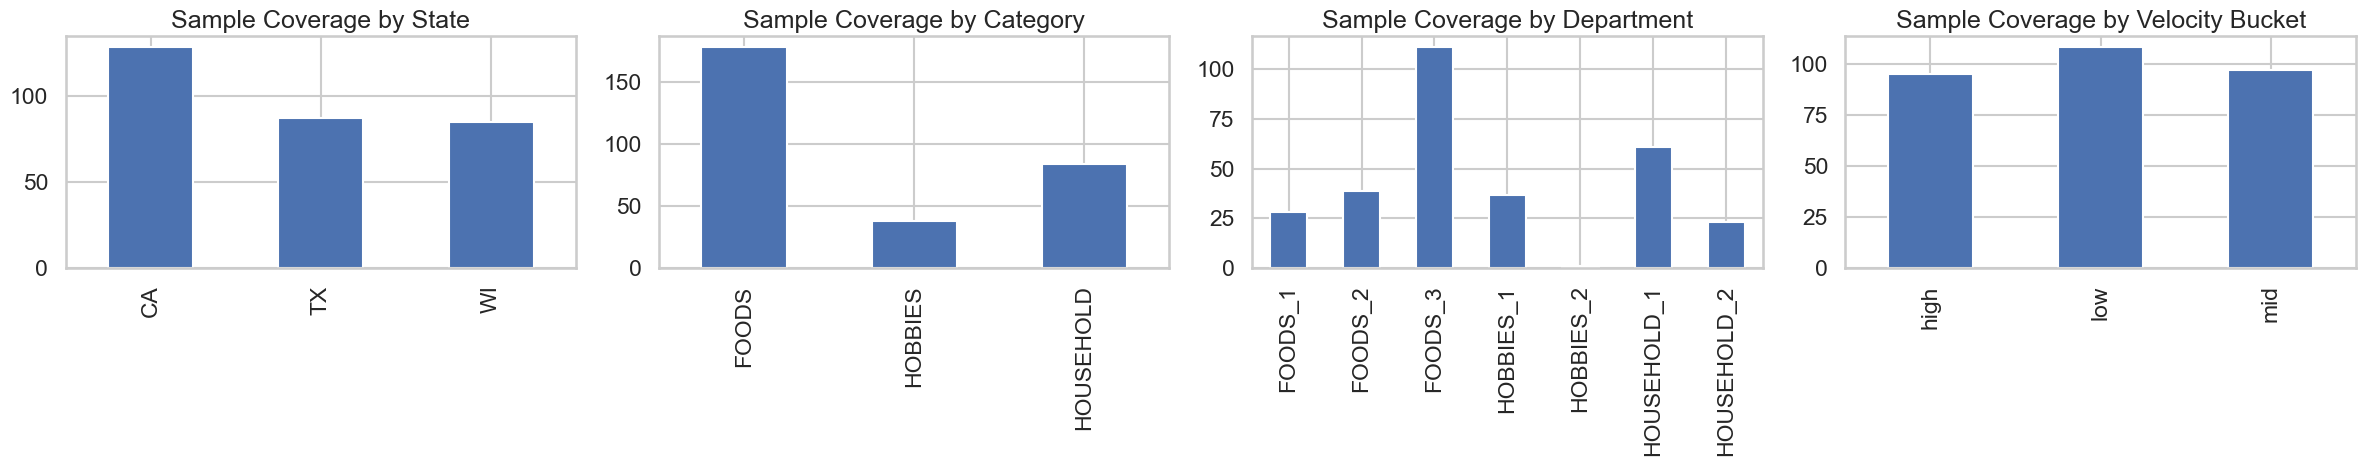

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, col, title in [
    (axes[0], 'state_name', 'Sample Coverage by State'),
    (axes[1], 'cat_name', 'Sample Coverage by Category'),
    (axes[2], 'dept_name', 'Sample Coverage by Department'),
    (axes[3], 'velocity_bucket', 'Sample Coverage by Velocity Bucket'),
]:
    sample_metadata[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


## Auto-ARIMA Order Search and SARIMA Forecasting

This cell executes the full plan path:
- `pmdarima.auto_arima()` on the sampled training series
- SARIMA refit for validation forecasting
- SARIMA refit on train+validation for test forecasting
- CSV outputs to `outputs/predictions/arima_val_preds.csv` and `outputs/predictions/arima_test_preds.csv`

If the outputs already exist and `REUSE_EXISTING_OUTPUTS=True`, they will be loaded instead of recomputed.


In [7]:
if REUSE_EXISTING_OUTPUTS and ARIMA_ORDER_LOG_PATH.exists() and ARIMA_VAL_PREDS_PATH.exists() and ARIMA_TEST_PREDS_PATH.exists():
    order_log_df = pd.read_csv(ARIMA_ORDER_LOG_PATH, converters={'order': eval, 'seasonal_order': eval})
    failures_df = pd.read_csv(ARIMA_FAILURES_PATH) if ARIMA_FAILURES_PATH.exists() else pd.DataFrame(columns=['id', 'error'])
    val_preds_df = pd.read_csv(ARIMA_VAL_PREDS_PATH, parse_dates=['date'])
    test_preds_df = pd.read_csv(ARIMA_TEST_PREDS_PATH, parse_dates=['date'])
else:
    train_sample_df = train_df[train_df['id'].isin(sample_ids)].copy()
    val_sample_df = val_df[val_df['id'].isin(sample_ids)].copy()
    test_sample_df = test_df[test_df['id'].isin(sample_ids)].copy()

    order_log_df, failures_df, val_preds_df, test_preds_df = run_arima_baseline(
        train_sample_df,
        val_sample_df,
        test_sample_df,
        sample_ids,
    )

print(f'Order log rows: {len(order_log_df):,}')
print(f'Failures: {len(failures_df):,}')
print(f'Validation predictions: {len(val_preds_df):,}')
print(f'Test predictions: {len(test_preds_df):,}')
display(order_log_df.head())
if not failures_df.empty:
    display(failures_df.head())


/Users/dhruvyellanki/Desktop/Transformer-Based-Retail-Demand-Forecasting-Using-Time-Series-Data/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/dhruvyellanki/Desktop/Transformer-Based-Retail-Demand-Forecasting-Using-Time-Series-Data/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/dhruvyellanki/Desktop/Transformer-Based-Retail-Demand-Forecasting-Using-Time-Series-Data/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/dhruvyellanki/Desktop

Order log rows: 300
Failures: 49
Validation predictions: 7,028
Test predictions: 7,028


,id,order,seasonal_order,aic,exog_cols
0,HOBBIES_1_144_CA_4_evaluation,"(0, 1, 1)","(1, 0, 1, 7)",3990.949412,"is_weekend,is_event,is_snap,sell_price"
1,HOBBIES_1_367_TX_1_evaluation,"(0, 1, 1)","(0, 0, 0, 7)",4578.298814,"is_weekend,is_event,is_snap,sell_price"
2,HOBBIES_1_324_WI_1_evaluation,"(3, 1, 1)","(2, 0, 0, 7)",4640.016110,"is_weekend,is_event,is_snap,sell_price"
3,FOODS_1_019_WI_3_evaluation,"(3, 1, 1)","(1, 0, 1, 7)",9075.354163,"is_weekend,is_event,is_snap,sell_price"
4,HOBBIES_1_097_WI_3_evaluation,"(1, 0, 1)","(0, 0, 0, 7)",4041.397991,"is_weekend,is_event,is_snap,sell_price"


,id,error
0,FOODS_3_290_TX_2_evaluation,A constant trend was included in the model spe...
1,FOODS_1_115_CA_3_evaluation,A constant trend was included in the model spe...
2,FOODS_1_051_CA_4_evaluation,A constant trend was included in the model spe...
3,FOODS_3_802_CA_1_evaluation,A constant trend was included in the model spe...
4,FOODS_3_154_CA_4_evaluation,A constant trend was included in the model spe...


In [8]:
order_modes = summarize_order_modes(order_log_df)
order_modes


{'p_mode': 0,
 'd_mode': 1,
 'q_mode': 1,
 'P_mode': 0,
 'D_mode': 0,
 'Q_mode': 0,
 'm_mode': 7,
 'order_mode': (0, 1, 1),
 'seasonal_order_mode': (0, 0, 0, 7)}

In [9]:
val_overall_metrics = compute_all_metrics(val_preds_df['actual'].values, val_preds_df['predicted'].values)
test_overall_metrics = compute_all_metrics(test_preds_df['actual'].values, test_preds_df['predicted'].values)

sample_metadata_for_merge = sample_metadata[['id', 'cat_name', 'dept_name', 'state_name']].copy()
val_cat_metrics = compute_group_metrics(val_preds_df, sample_metadata_for_merge.rename(columns={'cat_name': 'category'}), 'category')
val_dept_metrics = compute_group_metrics(val_preds_df, sample_metadata_for_merge.rename(columns={'dept_name': 'department'}), 'department')
test_cat_metrics = compute_group_metrics(test_preds_df, sample_metadata_for_merge.rename(columns={'cat_name': 'category'}), 'category')
test_dept_metrics = compute_group_metrics(test_preds_df, sample_metadata_for_merge.rename(columns={'dept_name': 'department'}), 'department')

print('Validation metrics:', val_overall_metrics)
print('Test metrics:', test_overall_metrics)
display(val_cat_metrics)
display(test_cat_metrics)
display(val_dept_metrics)
display(test_dept_metrics)


Validation metrics: {'MAE': 1.550116062957626, 'RMSE': 2.664369526956113, 'MAPE': 5269283017.395369}
Test metrics: {'MAE': 1.5775612163019856, 'RMSE': 2.9511614651421607, 'MAPE': 4094972137.7188735}


,category,MAE,RMSE,MAPE,rows
0,FOODS,1.701310,2.919222,5.490766e+09,4200
1,HOBBIES,1.528437,2.757145,5.233848e+09,1064
2,HOUSEHOLD,1.203206,1.845916,4.763316e+09,1764


,category,MAE,RMSE,MAPE,rows
0,FOODS,1.734884,3.296542,3.953502e+09,4200
1,HOBBIES,1.485025,2.523162,5.406484e+09,1064
2,HOUSEHOLD,1.258798,2.232688,3.640735e+09,1764


,department,MAE,RMSE,MAPE,rows
0,FOODS_1,1.881782,2.897802,6.378169e+09,672
1,FOODS_2,1.343334,1.947492,3.304723e+09,1008
2,FOODS_3,1.796375,3.232140,6.128542e+09,2520
3,HOBBIES_1,1.556232,2.792895,5.240160e+09,1036
4,HOBBIES_2,0.500032,0.510375,5.000316e+09,28
5,HOUSEHOLD_1,1.332905,2.053208,5.080935e+09,1232
6,HOUSEHOLD_2,0.902850,1.239218,4.027778e+09,532


,department,MAE,RMSE,MAPE,rows
0,FOODS_1,2.824963,5.875936,4.042061e+09,672
1,FOODS_2,1.320495,1.807350,3.163411e+09,1008
2,FOODS_3,1.609952,2.756497,4.245923e+09,2520
3,HOBBIES_1,1.512367,2.549836,5.539895e+09,1036
4,HOBBIES_2,0.473352,1.166055,4.702627e+08,28
5,HOUSEHOLD_1,1.397782,2.516307,3.845145e+09,1232
6,HOUSEHOLD_2,0.936941,1.365923,3.167364e+09,532


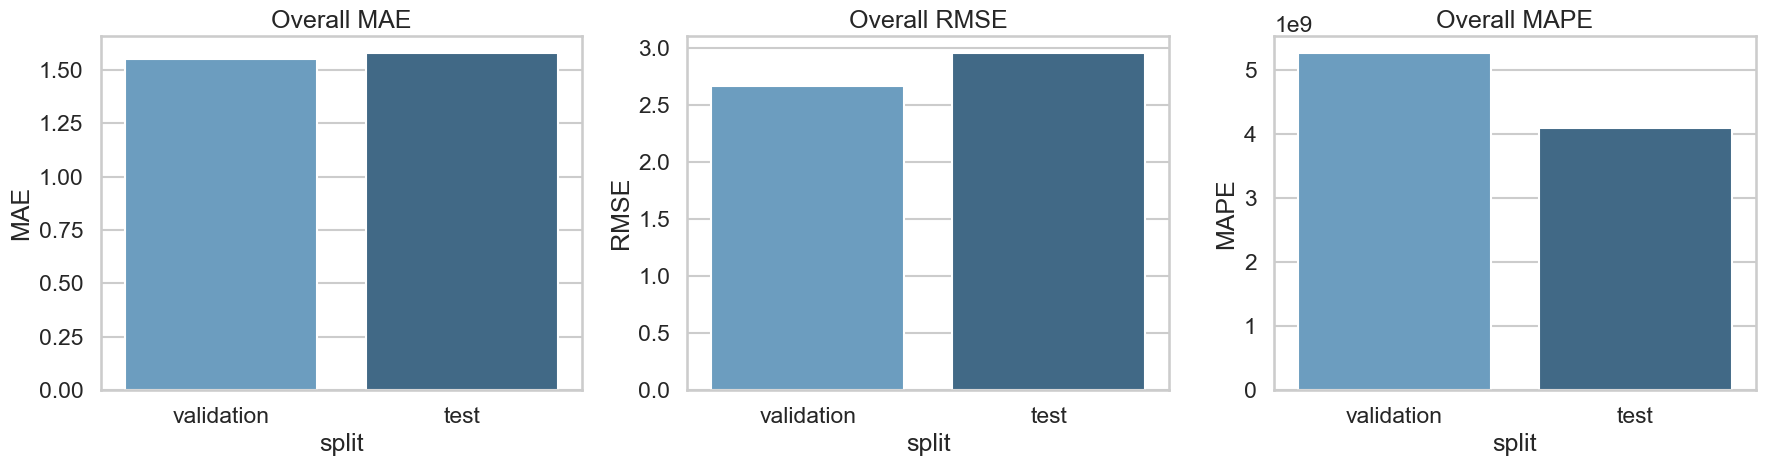

In [10]:
metrics_df = pd.DataFrame([
    {'split': 'validation', **val_overall_metrics},
    {'split': 'test', **test_overall_metrics},
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    sns.barplot(data=metrics_df, x='split', y=metric, ax=ax, palette='Blues_d')
    ax.set_title(f'Overall {metric}')
plt.tight_layout()
plt.show()


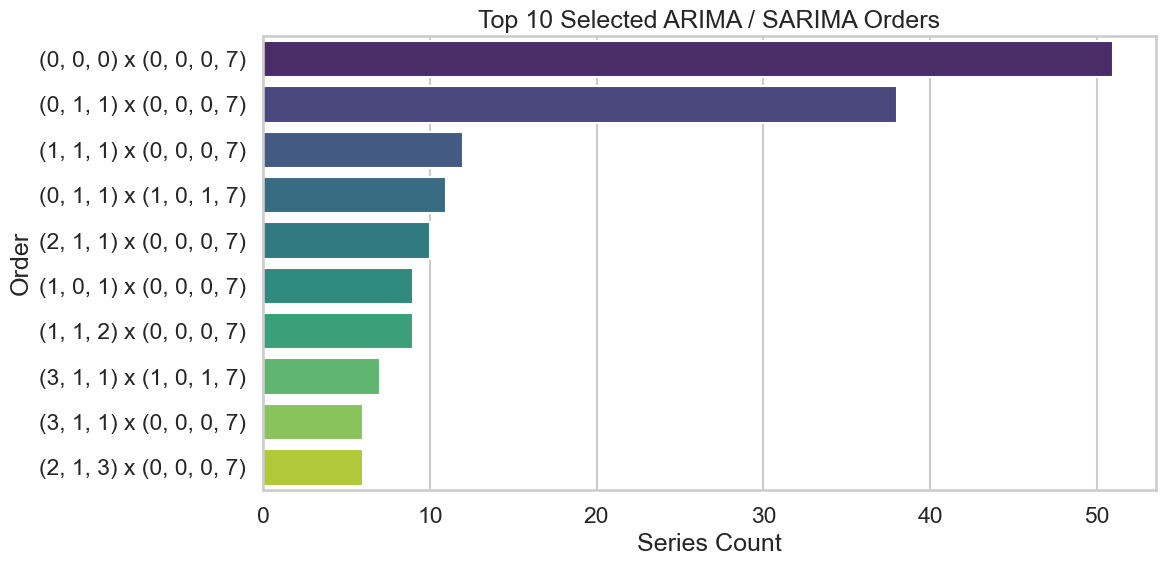

In [11]:
top_orders = order_log_df.copy()
top_orders['order_label'] = top_orders['order'].astype(str) + ' x ' + top_orders['seasonal_order'].astype(str)
order_counts = top_orders['order_label'].value_counts().head(10).reset_index()
order_counts.columns = ['order_label', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=order_counts, y='order_label', x='count', palette='viridis')
plt.title('Top 10 Selected ARIMA / SARIMA Orders')
plt.xlabel('Series Count')
plt.ylabel('Order')
plt.tight_layout()
plt.show()


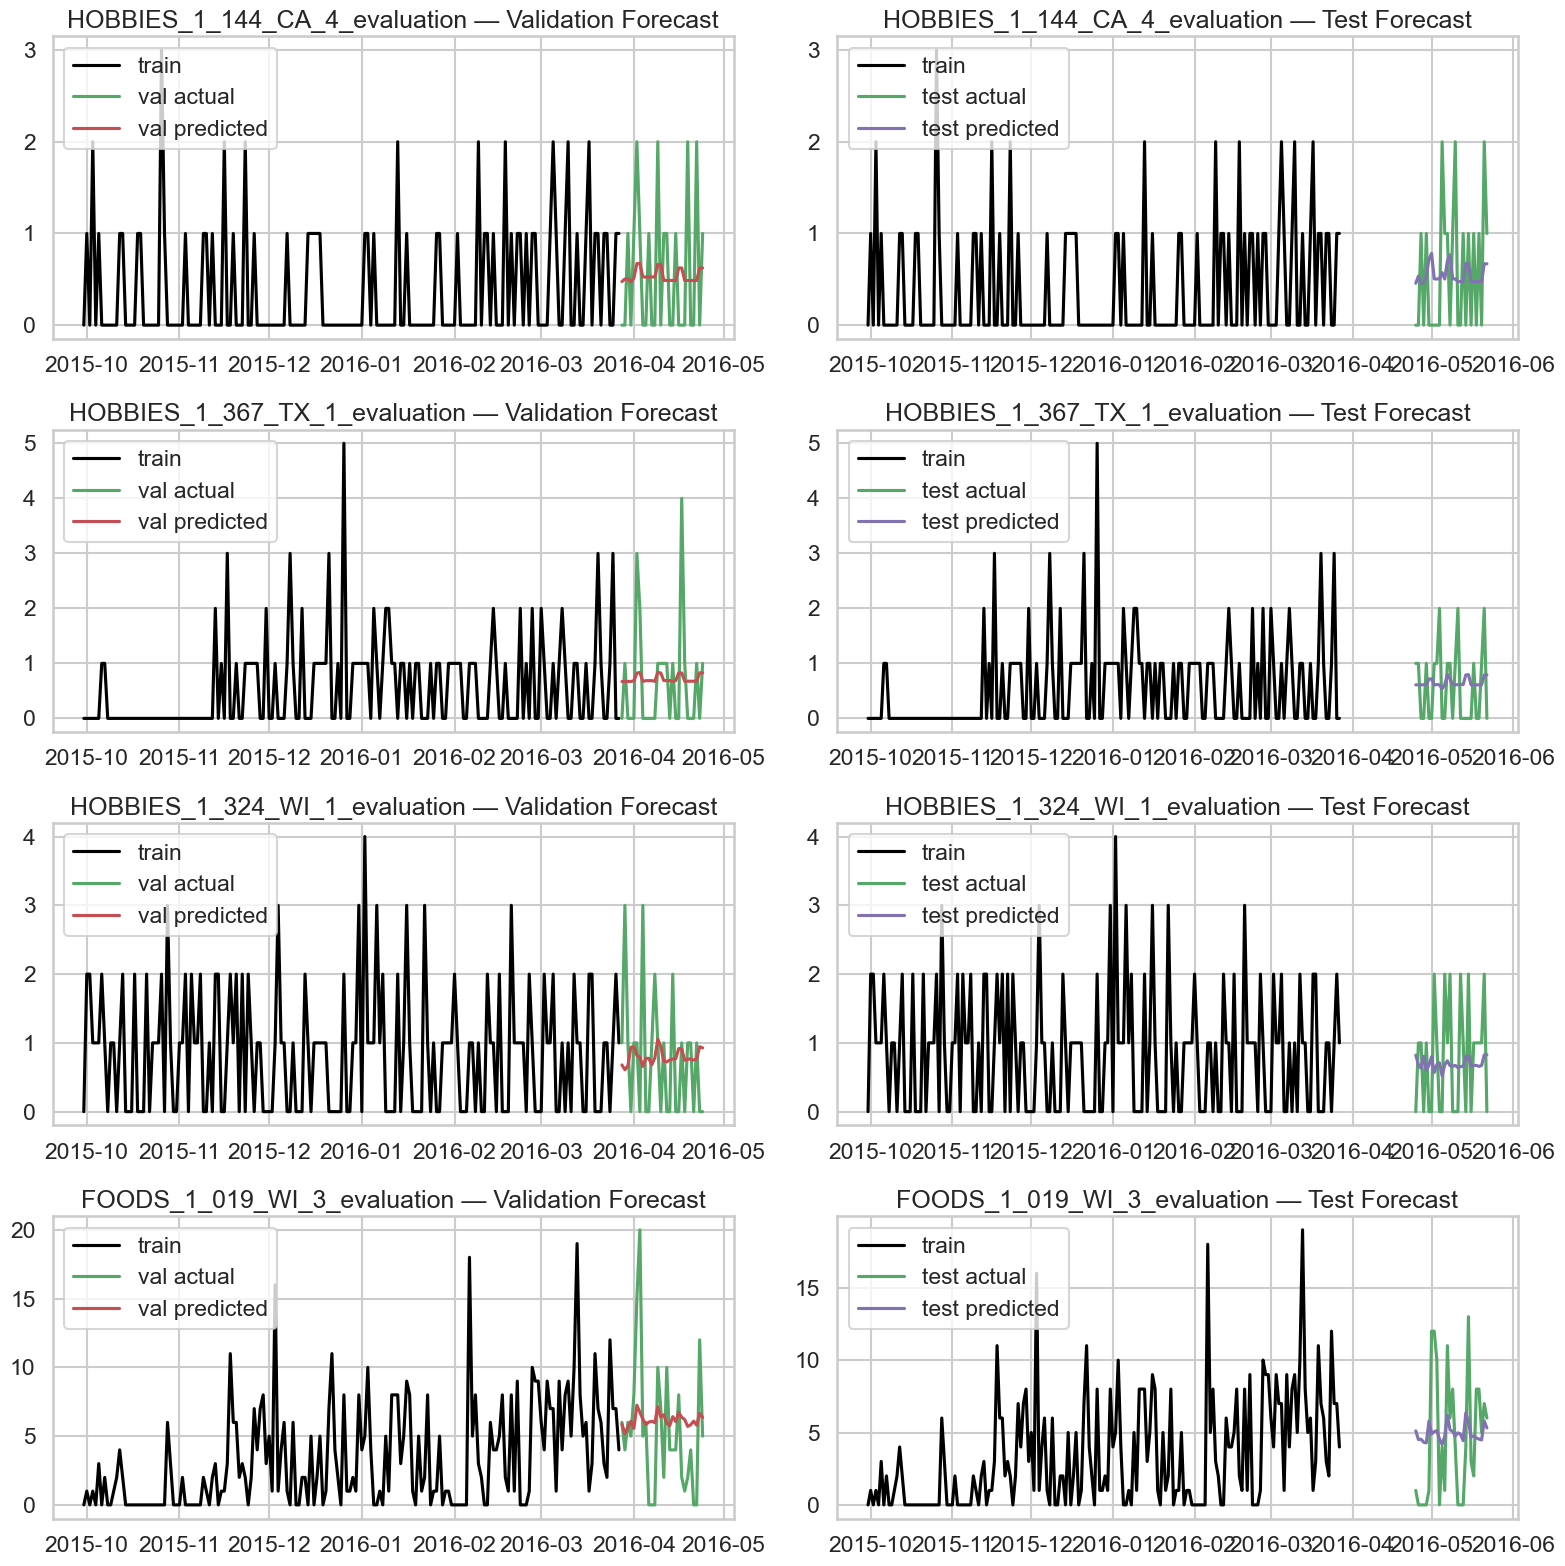

In [12]:
example_ids = order_log_df['id'].head(4).tolist()
fig, axes = plt.subplots(len(example_ids), 2, figsize=(16, 4 * len(example_ids)), sharex=False)
if len(example_ids) == 1:
    axes = np.array([axes])

for idx, series_id in enumerate(example_ids):
    train_series = train_df[train_df['id'] == series_id].sort_values('date')
    val_series = val_preds_df[val_preds_df['id'] == series_id].sort_values('date')
    test_series = test_preds_df[test_preds_df['id'] == series_id].sort_values('date')

    axes[idx, 0].plot(train_series['date'].tail(180), train_series['sales'].tail(180), label='train', color='black')
    axes[idx, 0].plot(val_series['date'], val_series['actual'], label='val actual', color='#55A868')
    axes[idx, 0].plot(val_series['date'], val_series['predicted'], label='val predicted', color='#C44E52')
    axes[idx, 0].set_title(f'{series_id} — Validation Forecast')
    axes[idx, 0].legend(loc='upper left')

    axes[idx, 1].plot(train_series['date'].tail(180), train_series['sales'].tail(180), label='train', color='black')
    axes[idx, 1].plot(test_series['date'], test_series['actual'], label='test actual', color='#55A868')
    axes[idx, 1].plot(test_series['date'], test_series['predicted'], label='test predicted', color='#8172B2')
    axes[idx, 1].set_title(f'{series_id} — Test Forecast')
    axes[idx, 1].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [13]:
mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment("arima_baseline")

val_cat_metrics.to_csv('outputs/predictions/arima_val_metrics_by_category.csv', index=False)
val_dept_metrics.to_csv('outputs/predictions/arima_val_metrics_by_department.csv', index=False)
test_cat_metrics.to_csv('outputs/predictions/arima_test_metrics_by_category.csv', index=False)
test_dept_metrics.to_csv('outputs/predictions/arima_test_metrics_by_department.csv', index=False)

log_metrics_to_mlflow(
    overall_val_metrics=val_overall_metrics,
    overall_test_metrics=test_overall_metrics,
    sample_size=len(sample_ids),
    failed_series_count=len(failures_df),
)

print('MLflow metrics logged to local tracking store at ./mlruns')


2026/04/03 03:54:36 INFO mlflow.tracking.fluent: Experiment with name 'arima_baseline' does not exist. Creating a new experiment.


MLflow metrics logged to local tracking store at ./mlruns


## Phase 6 Deliverables

This notebook produces the plan-required artifacts:
- `configs/arima_sample_ids.txt`
- `outputs/predictions/arima_orders.csv`
- `outputs/predictions/arima_failures.csv`
- `outputs/predictions/arima_val_preds.csv`
- `outputs/predictions/arima_test_preds.csv`
- grouped metric CSVs for category and department analysis

Interpretation guidance:
- validation metrics are used to understand baseline fit quality and tuning risk
- test metrics are for final hold-out comparison against later LSTM / Informer / TFT models
- any later deep model should beat this baseline to justify added complexity
